# PARcast — E_d(z,PAR) figures (all samples, no binning)

**An open-source DIY tool for the [PARcast](https://github.com/LoriAzniveBerberian/PARcast) PAR-profiling system.**

Reads **one in-water file** and writes figures to `<FIG_BASE>/E_dzPAR/<shortname>_<datafile>.png`, while also showing them inline. Unlike the earlier notebooks, nothing is binned or aggregated by depth — every figure shows the raw samples.

**Figures:** timeline, depth_profile, temp_profile, kd_fit, logx_profile, percast_fits, kd_variability

**How to use:** set `ED_PROFILE_CSV` below, then Run All.

### test files 

Pool (csv structure might be different look at v1 of jupyter notebook)
E_dzPAR_20260524 and 25 however ending nomenclature changes after 25 

Kramer's cove
E_dzPAR_20260604_0001.CSV

Kramer's cove
E_dzPAR_20260605_0003.CSV

NASA SARP cruise in the Texas Gulf 
E_dzPAR_20260608_0001.CSV;
E_sPAR_20260608_0001.CSV
* refere to field notes, there were casts where we lowered into 0.1-0.5m of water and pulled instument back on deck to change heading of vessel relative to swell and current.

## Config
Edit the file path and (rarely) the calibration / cast settings.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

# ---- file in / figures out ----
ED_PROFILE_CSV = '/Users/loriberberian/Desktop/PARcast/data_processing/raw/E_dzPAR/E_dzPAR_20260714_0001.CSV'
FIG_BASE       = '/Users/loriberberian/Desktop/PARcast/data_processing/figures'

# ---- calibration: rebuild PPFD from RAW par_mV ----
ED_SENSITIVITY  = 100.0     # umol m-2 s-1 per mV (SQ-500 factory sensitivity)
IECF            = 1.32      # Apogee immersion correction, SQ-500 (1.08 for SQ-120)
APPLY_IMMERSION = True      # False -> pre-immersion (relative) scale

# ---- analysis settings ----
TILT_OK_DEG = 5.0           # cosine collector trusted below this tilt (deg)
MIN_ED      = 0          # umol m-2 s-1: below this the sensor is effectively dark

# ---- cast isolation ----
CAST_MODE       = "auto"    # "auto" | "manual" | "all"
CAST_START      = None      # "2026-06-04 13:08" (manual only)
CAST_END        = None      # "2026-06-04 13:20"
CAST_ACTIVITY_M = 0.15      # auto: min rolling depth std (m) to count as moving
CAST_DIRECTION  = "down"    # "down" | "up" | "both"

# ---- per-cast Kd fit (no binning - regress on all samples in each cast) ----
MIN_PTS_PER_CAST = 30
MIN_SPAN_M       = 1.0

IMU_UP_AXIS = "accel_y_ms2"
DEPTH_MIN_M, TEMP_MIN_C = -10.0, -10.0

# ---- output folder + figure naming ----
STEM   = os.path.splitext(os.path.basename(ED_PROFILE_CSV))[0]   # e.g. E_dzPAR_20260608_0001
OUTDIR = os.path.join(FIG_BASE, "E_dzPAR")
os.makedirs(OUTDIR, exist_ok=True)

def savefig(fig, shortname):
    """Write <shortname>_<datafile>.png into the E_dzPAR figures folder."""
    path = os.path.join(OUTDIR, f"{shortname}_{STEM}.png")
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print("saved", path)

print("figures will be written to:", OUTDIR)

figures will be written to: /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR


## Functions
Load / clean / tilt / cast detection, plus per-cast K_d (each cast = one replicate, fit on all samples). You usually don't need to touch this.

In [2]:
def compute_tilt(df):
    mag = np.sqrt(df.accel_x_ms2**2 + df.accel_y_ms2**2 + df.accel_z_ms2**2)
    return np.degrees(np.arccos(np.clip(df[IMU_UP_AXIS] / mag, -1, 1)))

def load_profile(path):
    df = pd.read_csv(path, parse_dates=["iso_time"]).sort_values("iso_time").reset_index(drop=True)
    n0 = len(df)
    df = df[(df.depth_m > DEPTH_MIN_M) & (df.water_temp_C > TEMP_MIN_C)
            & (df.pressure_mbar > 0)].reset_index(drop=True)
    df.attrs["glitch_rows_dropped"] = n0 - len(df)
    df["tilt_deg"] = compute_tilt(df)
    immersion = IECF if APPLY_IMMERSION else 1.0
    df["Ed"] = df["par_mV"] * ED_SENSITIVITY * immersion
    return df

def add_cast_flag(profile, activity_m=CAST_ACTIVITY_M, window=80):
    p = profile.copy()
    p["depth_activity"] = p["depth_m"].rolling(window, center=True, min_periods=20).std()
    p["profiling"] = p["depth_activity"] > activity_m
    dt = p["iso_time"].diff().dt.total_seconds().replace(0, np.nan)
    p["vspeed"] = p["depth_m"].diff() / dt
    vs = p["vspeed"].rolling(window, center=True, min_periods=10).median()
    p["direction"] = np.where(vs >= 0, "down", "up")
    return p

def select_cast(profile, mode="auto", start=None, end=None,
                activity_m=CAST_ACTIVITY_M, direction="both"):
    p = add_cast_flag(profile, activity_m)
    if mode == "manual" and start and end:
        t0, t1 = pd.Timestamp(start), pd.Timestamp(end)
        cast0 = p[(p["iso_time"] >= t0) & (p["iso_time"] <= t1)].copy()
    elif mode == "auto" and p["profiling"].any():
        cast0 = p[p["profiling"]].copy()                 # only actually-moving samples
        t0, t1 = cast0["iso_time"].min(), cast0["iso_time"].max()
    else:
        cast0 = p.copy(); t0, t1 = p["iso_time"].min(), p["iso_time"].max()
    cast = cast0
    if direction in ("down", "up"):
        cast = cast[cast["direction"] == direction].copy()
    return cast, t0, t1

def label_casts(profile, activity_m=CAST_ACTIVITY_M, max_gap_s=5.0):
    p = add_cast_flag(profile, activity_m)
    p = p[p["profiling"]].copy()
    if p.empty:
        p["cast_id"] = pd.Series(dtype=int); return p
    dir_change = p["direction"].ne(p["direction"].shift())
    gap = p["iso_time"].diff().dt.total_seconds().gt(max_gap_s)
    p["cast_id"] = (dir_change | gap).cumsum()
    return p

def fit_kd_segment(seg, value_col="Ed", min_val=MIN_ED, min_n=MIN_PTS_PER_CAST):
    """Regress ln(value) on depth for ONE cast using ALL lit samples (no bins)."""
    s = seg[seg[value_col] > min_val].copy()
    if len(s) < min_n or (s.depth_m.max() - s.depth_m.min()) < MIN_SPAN_M:
        return None
    s["lnE"] = np.log(s[value_col])
    f = stats.linregress(s.depth_m, s.lnE)
    return dict(Kd=-f.slope, r2=f.rvalue**2, slope_se=f.stderr, n_pts=len(s),
                z0=s.depth_m.min(), z1=s.depth_m.max(),
                slope=f.slope, intercept=f.intercept, samples=s)

def fit_kd_per_cast(profile, direction=CAST_DIRECTION, value_col="Ed"):
    p = label_casts(profile)
    if direction in ("down", "up"):
        p = p[p["direction"] == direction]
    rows, fits = [], {}
    for cid, seg in p.groupby("cast_id"):
        r = fit_kd_segment(seg, value_col=value_col)
        if r is None:
            continue
        lab = len(rows) + 1; fits[lab] = r
        rows.append(dict(cast=lab, direction=seg.direction.iloc[0],
                         t_start=seg.iso_time.min(), z0=r["z0"], z1=r["z1"],
                         n_pts=r["n_pts"], tilt_med=seg.tilt_deg.median(),
                         Kd=r["Kd"], r2=r["r2"], slope_se=r["slope_se"]))
    return pd.DataFrame(rows), fits

def kd_ensemble_stats(tbl):
    """Honest Kd: each cast = one replicate, uncertainty = spread ACROSS casts."""
    k = tbl["Kd"].to_numpy(); n = len(k)
    if n == 0:
        return {}
    mean = k.mean(); sd = k.std(ddof=1) if n > 1 else np.nan
    se = sd / np.sqrt(n) if n > 1 else np.nan
    tcrit = stats.t.ppf(0.975, n - 1) if n > 1 else np.nan
    return dict(n=n, mean=mean, sd=sd, se=se,
                ci_lo=mean - tcrit * se if n > 1 else np.nan,
                ci_hi=mean + tcrit * se if n > 1 else np.nan,
                median=float(np.median(k)),
                cv=100 * sd / mean if n > 1 else np.nan)

print("functions ready")

functions ready


## Load and identify the cast

In [3]:
profile = load_profile(ED_PROFILE_CSV)
cast, cast_t0, cast_t1 = select_cast(profile, CAST_MODE, CAST_START, CAST_END,
                                     CAST_ACTIVITY_M, CAST_DIRECTION)
print(f"{len(profile)} rows, {profile.attrs.get('glitch_rows_dropped', 0)} glitches dropped")
print(f"depth {profile.depth_m.min():.2f}-{profile.depth_m.max():.2f} m, "
      f"cast {CAST_DIRECTION}: {len(cast)} rows, tilt median {cast.tilt_deg.median():.0f} deg")
cast.head(3)

48640 rows, 0 glitches dropped
depth -2.53-2.08 m, cast down: 1634 rows, tilt median 4 deg


,iso_time,unix_time,par_mV,par_uMol_m2_s,depth_m,pressure_mbar,water_temp_C,accel_x_ms2,accel_y_ms2,accel_z_ms2,...,roll_deg,pitch_deg,yaw_deg,imu_temp_C,tilt_deg,Ed,depth_activity,profiling,vspeed,direction
30623,2026-07-14 20:11:35,1784059895,20.5547,2055.47,-1.271,884.7,24.72,-1.239,9.753,0.435,...,88.16,6.09,269.99,33.94,7.668187,2713.2204,0.152789,True,NaN,down
30624,2026-07-14 20:11:35,1784059895,20.6719,2067.19,-1.272,884.6,24.62,-1.083,9.848,0.550,...,87.80,5.93,270.38,33.95,7.031370,2728.6908,0.155696,True,NaN,down
30625,2026-07-14 20:11:35,1784059895,20.6406,2064.06,-1.281,883.7,24.61,-0.007,10.019,1.013,...,87.58,4.74,270.73,33.96,5.773572,2724.5592,0.158045,True,NaN,down


## Figure: timeline
Whole deployment on one clock — in-water PAR, depth, water temperature, tilt. Shaded band = the profiling cast.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/timeline_E_dzPAR_20260714_0001.png


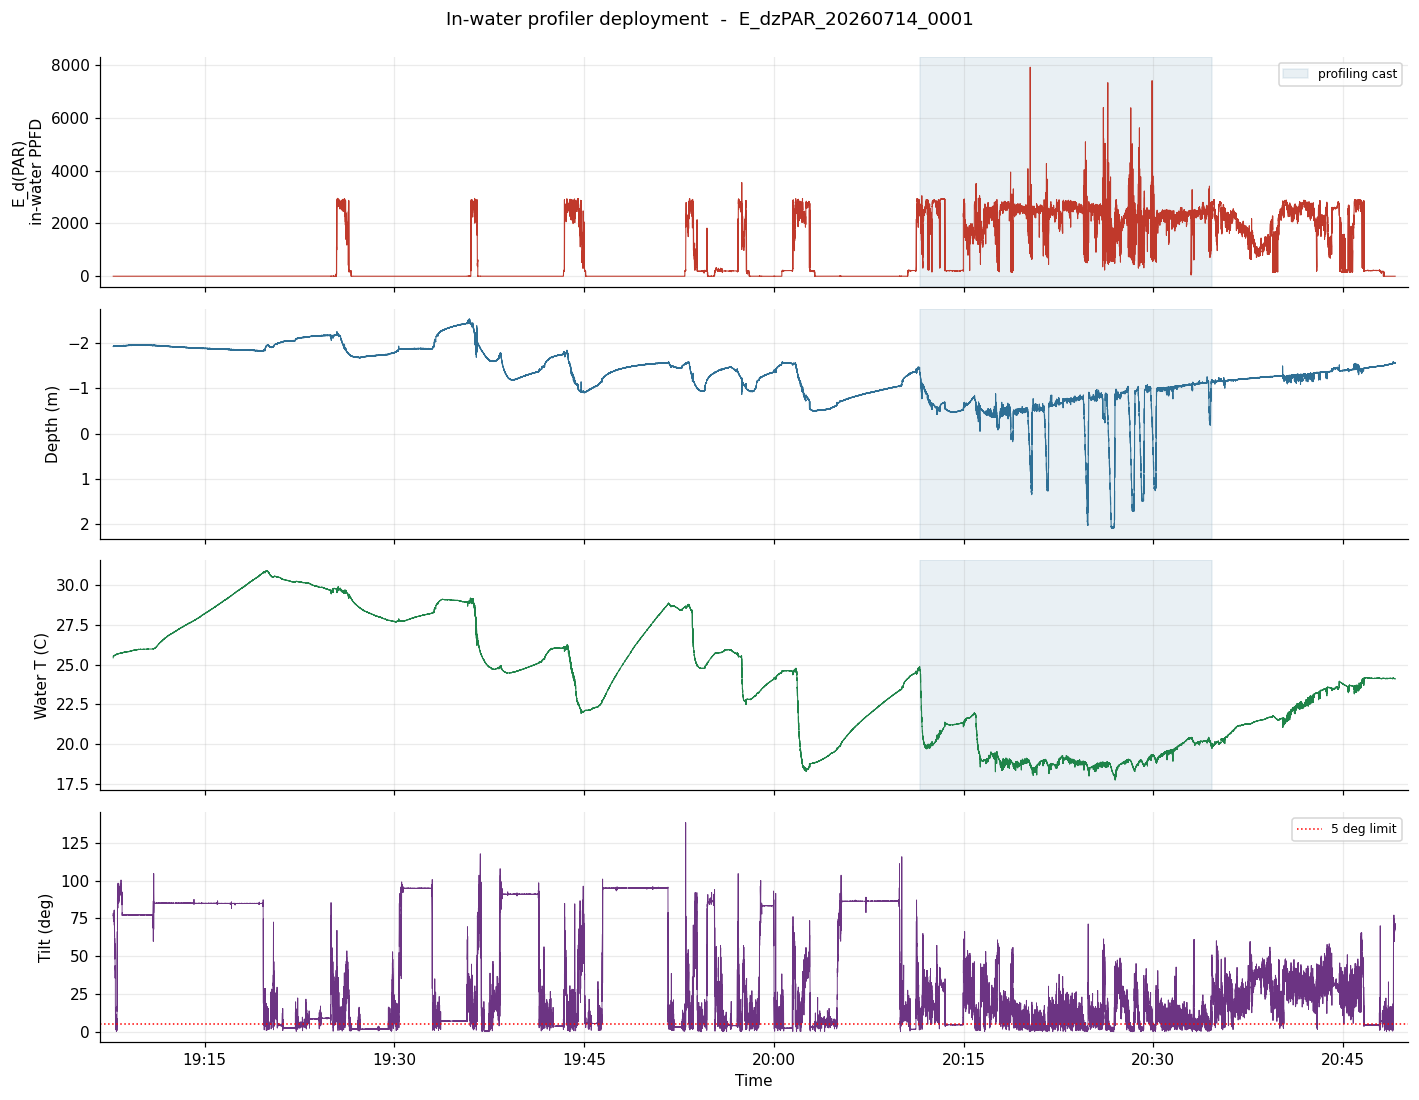

In [4]:
fig, ax = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
ax[0].plot(profile.iso_time, profile.Ed, color="#c0392b", lw=0.7)
ax[0].axvspan(cast_t0, cast_t1, color="#2e6f95", alpha=0.10, label="profiling cast")
ax[0].set_ylabel("E_d(PAR)\nin-water PPFD"); ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(profile.iso_time, profile.depth_m, color="#2e6f95", lw=0.7)
ax[1].axvspan(cast_t0, cast_t1, color="#2e6f95", alpha=0.10)
ax[1].invert_yaxis(); ax[1].set_ylabel("Depth (m)")
ax[2].plot(profile.iso_time, profile.water_temp_C, color="#1e8449", lw=0.7)
ax[2].axvspan(cast_t0, cast_t1, color="#2e6f95", alpha=0.10); ax[2].set_ylabel("Water T (C)")
ax[3].plot(profile.iso_time, profile.tilt_deg, color="#6c3483", lw=0.6)
ax[3].axhline(TILT_OK_DEG, color="red", ls=":", lw=1, label=f"{TILT_OK_DEG:.0f} deg limit")
ax[3].set_ylabel("Tilt (deg)"); ax[3].set_xlabel("Time"); ax[3].legend(loc="upper right", fontsize=8)
ax[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
for a in ax: a.margins(x=0.01)
fig.suptitle(f"In-water profiler deployment  -  {STEM}", y=0.995)
fig.tight_layout(); savefig(fig, "timeline"); plt.show()

## Figure: depth_profile
PAR vs depth, every sample. Grey = parked / drifting context; coloured = cast samples coloured by tilt. No binned line.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/depth_profile_E_dzPAR_20260714_0001.png


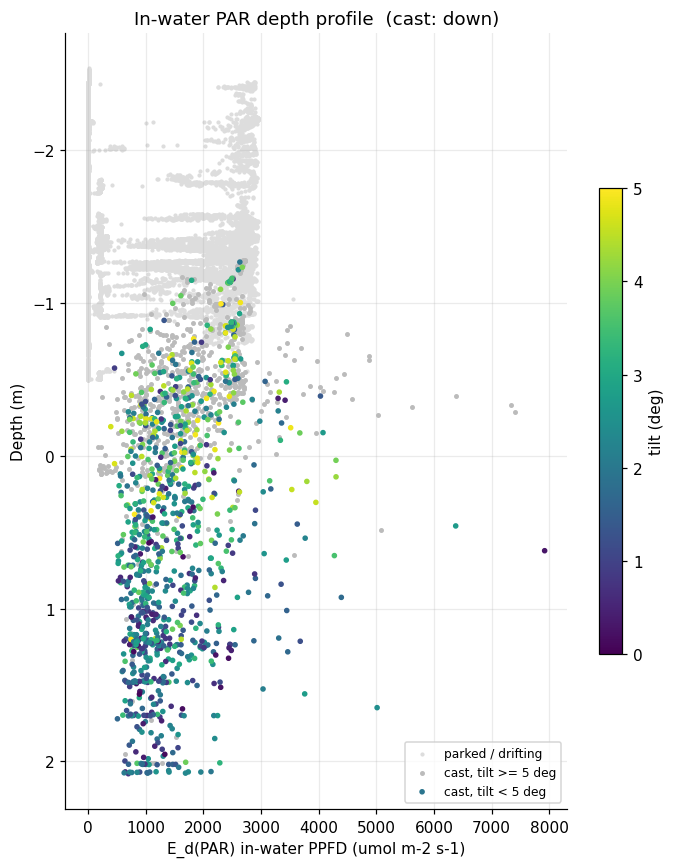

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 8))
parked = profile[(profile.iso_time < cast_t0) | (profile.iso_time > cast_t1)]
ax.scatter(parked.Ed, parked.depth_m, s=3, c="#dddddd", label="parked / drifting", zorder=1)
tilted = cast[cast.tilt_deg >= TILT_OK_DEG]
level  = cast[cast.tilt_deg <  TILT_OK_DEG]
ax.scatter(tilted.Ed, tilted.depth_m, s=5, c="#bbbbbb",
           label=f"cast, tilt >= {TILT_OK_DEG:.0f} deg", zorder=2)
sc = ax.scatter(level.Ed, level.depth_m, s=7, c=level.tilt_deg, cmap="viridis",
                vmin=0, vmax=TILT_OK_DEG, label=f"cast, tilt < {TILT_OK_DEG:.0f} deg", zorder=3)
ax.invert_yaxis()
ax.set_xlabel("E_d(PAR) in-water PPFD (umol m-2 s-1)"); ax.set_ylabel("Depth (m)")
ax.set_title(f"In-water PAR depth profile  (cast: {CAST_DIRECTION})")
fig.colorbar(sc, ax=ax, label="tilt (deg)", shrink=0.6)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); savefig(fig, "depth_profile"); plt.show()

## Figure: temp_profile
Water temperature vs depth, every sample, coloured by time into the deployment.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/temp_profile_E_dzPAR_20260714_0001.png


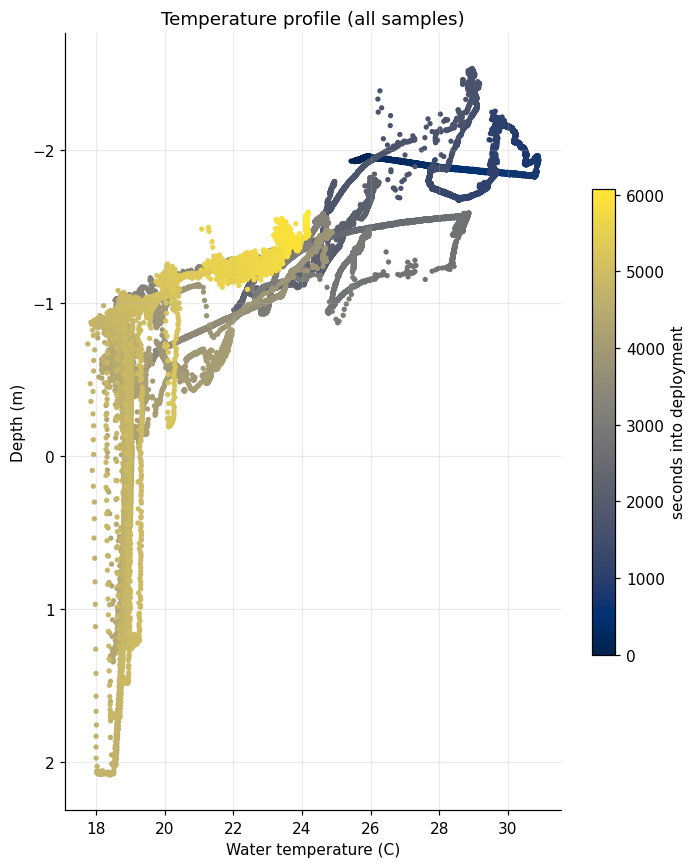

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 8))
t_rel = (profile.iso_time - profile.iso_time.min()).dt.total_seconds()
sc = ax.scatter(profile.water_temp_C, profile.depth_m, s=6, c=t_rel, cmap="cividis")
ax.invert_yaxis()
ax.set_xlabel("Water temperature (C)"); ax.set_ylabel("Depth (m)")
ax.set_title("Temperature profile (all samples)")
fig.colorbar(sc, ax=ax, label="seconds into deployment", shrink=0.6)
fig.tight_layout(); savefig(fig, "temp_profile"); plt.show()

## Figure: kd_fit
Pooled `ln(E_d)` vs depth, fit on **all** cast samples (no bins). The nominal R^2 / SE here are optimistic because the samples are autocorrelated — the honest uncertainty is the across-cast spread further down.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/kd_fit_E_dzPAR_20260714_0001.png


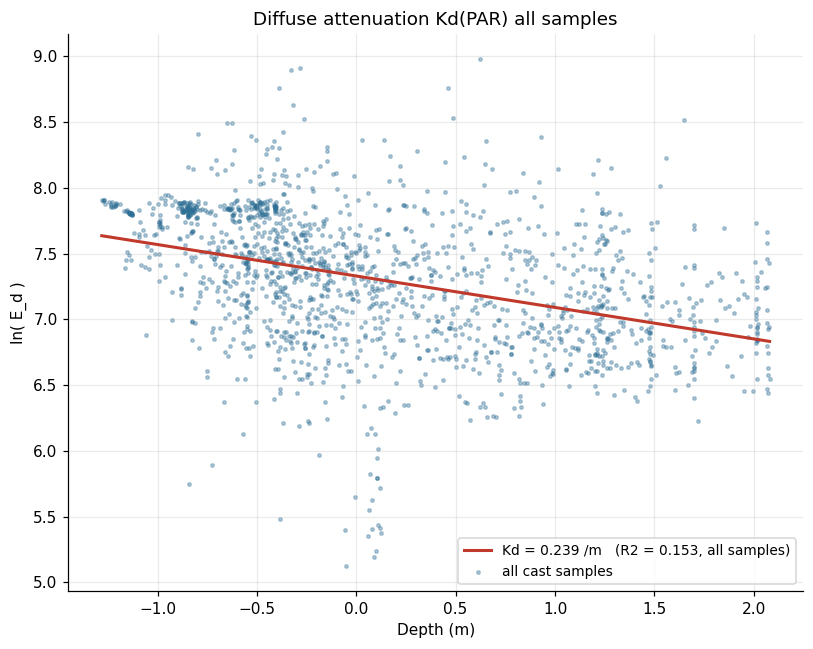

pooled Kd(PAR) = 0.239 /m (R2=0.153); nominal SE optimistic - use across-cast spread below


In [7]:
good = cast[cast.Ed > MIN_ED].copy()
good["lnEd"] = np.log(good.Ed)
fig, ax = plt.subplots(figsize=(7.5, 6))
Kd = None
if len(good) >= 3 and (good.depth_m.max() - good.depth_m.min()) > MIN_SPAN_M:
    fit = stats.linregress(good.depth_m, good.lnEd)
    Kd = -fit.slope
    xs = np.linspace(good.depth_m.min(), good.depth_m.max(), 50)
    ax.plot(xs, fit.intercept + fit.slope * xs, color="#c0392b", lw=2,
            label=f"Kd = {Kd:.3f} /m   (R2 = {fit.rvalue**2:.3f}, all samples)")
ax.scatter(good.depth_m, good.lnEd, s=5, c="#2e6f95", alpha=0.35, label="all cast samples")
ax.set_xlabel("Depth (m)"); ax.set_ylabel("ln( E_d )")
ax.set_title("Diffuse attenuation Kd(PAR) all samples")
ax.legend(fontsize=9)
fig.tight_layout(); savefig(fig, "kd_fit"); plt.show()
if Kd is not None:
    print(f"pooled Kd(PAR) = {Kd:.3f} /m (R2={fit.rvalue**2:.3f}); "
          "nominal SE optimistic - use across-cast spread below")

## Per-cast K_d
Fit every cast separately (all samples), so the spread across casts is the honest uncertainty.

In [8]:
kd_table, kd_fits = fit_kd_per_cast(profile, direction=CAST_DIRECTION, value_col="Ed")
kd_stats = kd_ensemble_stats(kd_table)
_cmap = plt.get_cmap("turbo")
_N = max(1, len(kd_table))
cast_color = {row.cast: _cmap(i / max(1, _N - 1)) for i, row in enumerate(kd_table.itertuples())}
if len(kd_table) == 0:
    print("No qualifying casts. Lower MIN_PTS_PER_CAST / MIN_SPAN_M or set CAST_DIRECTION='both'.")
else:
    _show = kd_table.copy(); _show["t_start"] = _show["t_start"].dt.strftime("%H:%M:%S")
    print(_show.round({"z0": 2, "z1": 2, "tilt_med": 1, "Kd": 3, "r2": 3, "slope_se": 4}).to_string(index=False))
kd_table

 cast direction  t_start    z0   z1  n_pts  tilt_med    Kd    r2  slope_se
    1      down 20:20:04 -0.55 1.34    175       3.0 0.330 0.286    0.0396
    2      down 20:21:22 -0.53 1.25    132       2.9 0.247 0.170    0.0479
    3      down 20:24:28 -0.85 2.02    200       2.8 0.141 0.072    0.0360
    4      down 20:26:09 -0.90 2.08    246       4.7 0.216 0.152    0.0326
    5      down 20:28:01 -0.96 1.70    174       2.7 0.180 0.103    0.0404
    6      down 20:28:48 -1.04 1.49    167       2.9 0.275 0.176    0.0464
    7      down 20:29:47 -1.03 1.23    156       3.8 0.240 0.130    0.0500


,cast,direction,t_start,z0,z1,n_pts,tilt_med,Kd,r2,slope_se
0,1,down,2026-07-14 20:20:04,-0.545,1.345,175,3.021597,0.329546,0.286140,0.039574
1,2,down,2026-07-14 20:21:22,-0.533,1.254,132,2.864428,0.247007,0.169980,0.047872
2,3,down,2026-07-14 20:24:28,-0.852,2.021,200,2.762113,0.140693,0.071690,0.035980
3,4,down,2026-07-14 20:26:09,-0.897,2.080,246,4.726894,0.216077,0.152424,0.032619
4,5,down,2026-07-14 20:28:01,-0.964,1.703,174,2.711853,0.179921,0.103313,0.040417
5,6,down,2026-07-14 20:28:48,-1.044,1.486,167,2.947520,0.275324,0.175575,0.046446
6,7,down,2026-07-14 20:29:47,-1.026,1.228,156,3.752260,0.239795,0.129760,0.050041


## Figure: logx_profile
Same profile on a log x-axis (straight = clean exponential decay), one colour per cast, all samples.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/logx_profile_E_dzPAR_20260714_0001.png


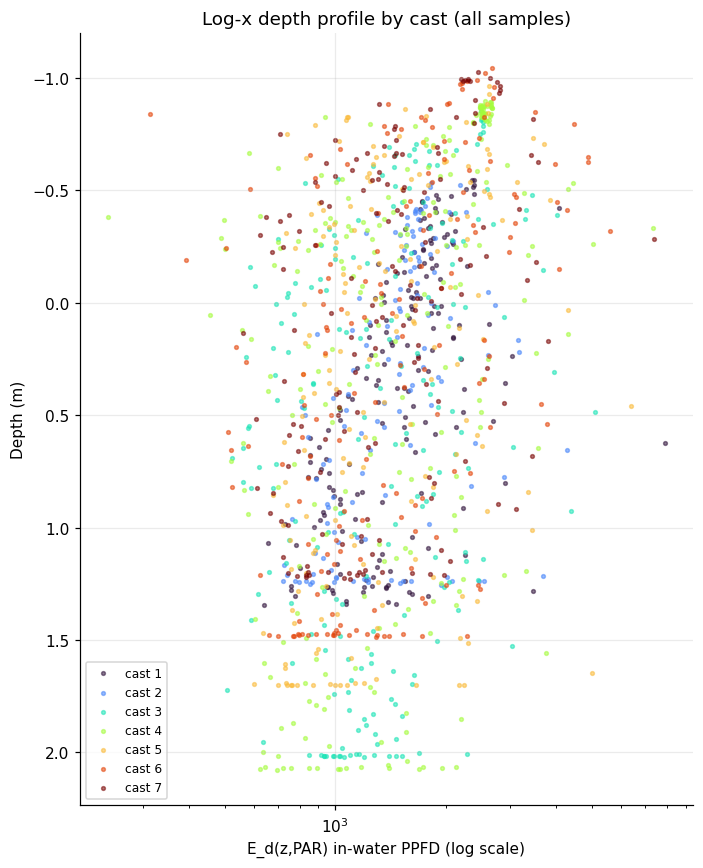

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 8))
for cid, r in kd_fits.items():
    s = r["samples"]
    ax.scatter(s["Ed"], s.depth_m, s=6, color=cast_color[cid], alpha=0.55, label=f"cast {cid}")
ax.set_xscale("log"); ax.invert_yaxis()
ax.set_xlabel("E_d(z,PAR) in-water PPFD (log scale)"); ax.set_ylabel("Depth (m)")
ax.set_title("Log-x depth profile by cast (all samples)")
if len(kd_fits): ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); savefig(fig, "logx_profile"); plt.show()

## Figure: percast_fits
Left: `ln(E_d)` vs depth, all samples with one regression line per cast (the fan-out *is* the K_d uncertainty). Right: residuals — structure flags non-exponential decay.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/percast_fits_E_dzPAR_20260714_0001.png


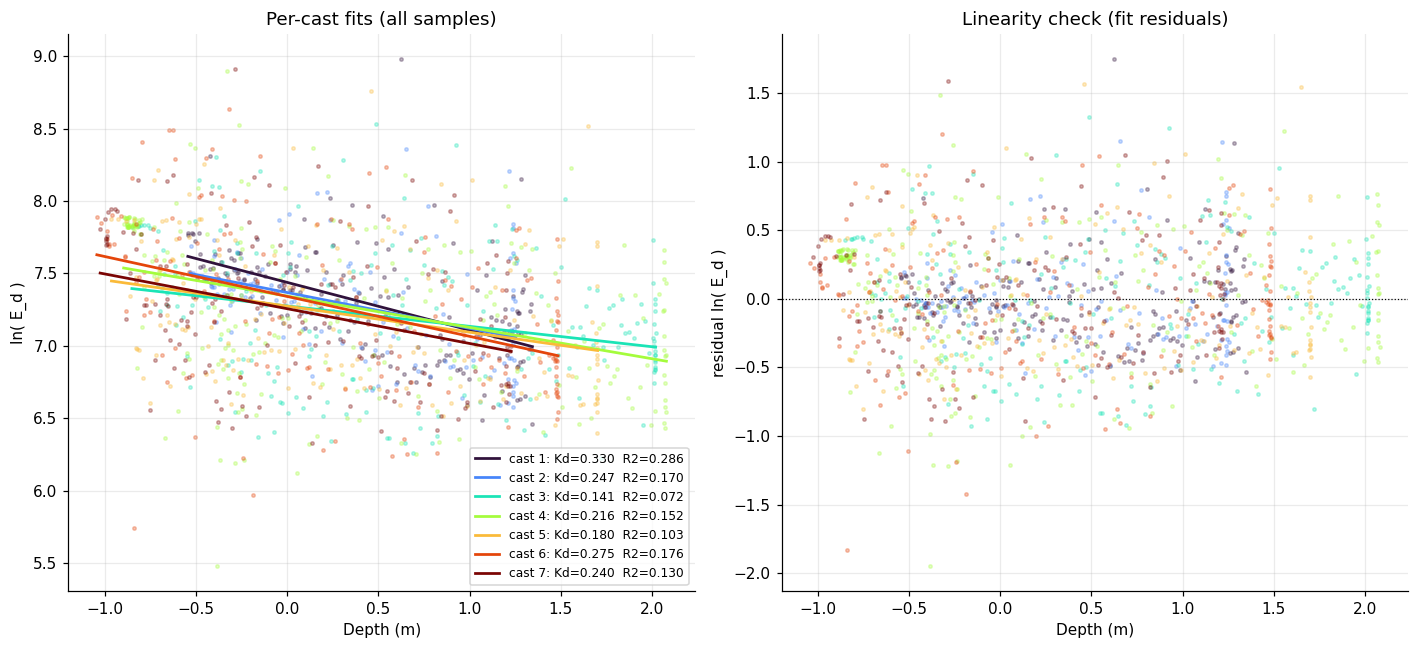

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6))
for cid, r in kd_fits.items():
    s = r["samples"]
    axL.scatter(s.depth_m, s.lnE, s=5, color=cast_color[cid], alpha=0.30)
    xs = np.linspace(s.depth_m.min(), s.depth_m.max(), 30)
    axL.plot(xs, r["intercept"] + r["slope"] * xs, color=cast_color[cid], lw=1.8,
             label=f"cast {cid}: Kd={r['Kd']:.3f}  R2={r['r2']:.3f}")
    axR.scatter(s.depth_m, s.lnE - (r["intercept"] + r["slope"] * s.depth_m),
                s=5, color=cast_color[cid], alpha=0.30)
axL.set_xlabel("Depth (m)"); axL.set_ylabel("ln( E_d )"); axL.set_title("Per-cast fits (all samples)")
if len(kd_fits): axL.legend(fontsize=8)
axR.axhline(0, color="k", lw=0.8, ls=":")
axR.set_xlabel("Depth (m)"); axR.set_ylabel("residual ln( E_d )")
axR.set_title("Linearity check (fit residuals)")
fig.tight_layout(); savefig(fig, "percast_fits"); plt.show()

## Figure: kd_variability
(a) per-cast K_d with across-cast mean + 95% CI, (b) K_d vs cast tilt (trend = wobble bias), (c) spread as one CV number.

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/E_dzPAR/kd_variability_E_dzPAR_20260714_0001.png


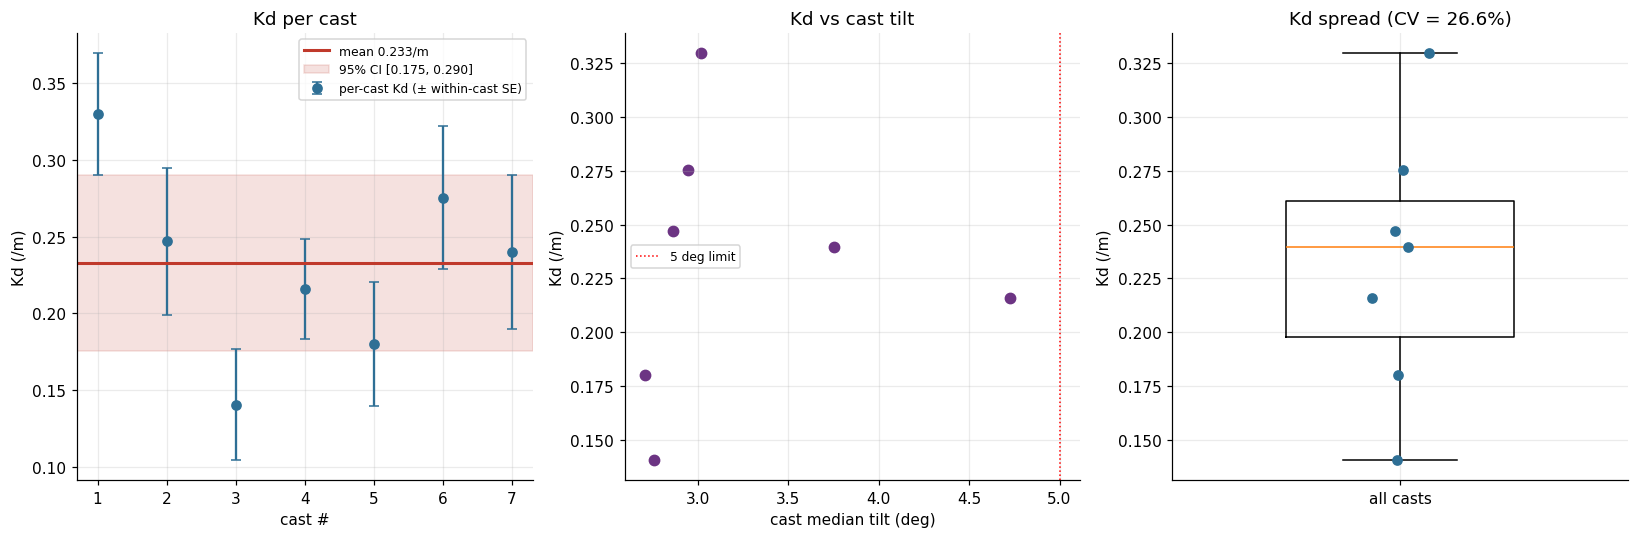

per-cast Kd = 0.233 +/- 0.062 /m (SD across 7 casts); 95% CI [0.175, 0.290]


In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
if len(kd_table):
    ax1.errorbar(kd_table.cast, kd_table.Kd, yerr=kd_table.slope_se, fmt="o",
                 color="#2e6f95", capsize=3, label="per-cast Kd (± within-cast SE)")
    if kd_stats["n"] > 1:
        ax1.axhline(kd_stats["mean"], color="#c0392b", lw=2, label=f"mean {kd_stats['mean']:.3f}/m")
        ax1.axhspan(kd_stats["ci_lo"], kd_stats["ci_hi"], color="#c0392b", alpha=0.15,
                    label=f"95% CI [{kd_stats['ci_lo']:.3f}, {kd_stats['ci_hi']:.3f}]")
ax1.set_xlabel("cast #"); ax1.set_ylabel("Kd (/m)"); ax1.set_title("Kd per cast"); ax1.legend(fontsize=8)
if len(kd_table):
    ax2.scatter(kd_table.tilt_med, kd_table.Kd, s=45, color="#6c3483")
ax2.axvline(TILT_OK_DEG, color="red", ls=":", lw=1, label=f"{TILT_OK_DEG:.0f} deg limit")
ax2.set_xlabel("cast median tilt (deg)"); ax2.set_ylabel("Kd (/m)")
ax2.set_title("Kd vs cast tilt"); ax2.legend(fontsize=8)
if len(kd_table):
    ax3.boxplot(kd_table.Kd, widths=0.5)
    ax3.scatter(np.ones(len(kd_table)) + np.random.normal(0, 0.03, len(kd_table)),
                kd_table.Kd, color="#2e6f95", zorder=3)
ax3.set_xticks([1]); ax3.set_xticklabels(["all casts"]); ax3.set_ylabel("Kd (/m)")
ax3.set_title(f"Kd spread (CV = {kd_stats.get('cv', float('nan')):.1f}%)")
fig.tight_layout(); savefig(fig, "kd_variability"); plt.show()

if kd_stats.get("n", 0) > 1:
    print(f"per-cast Kd = {kd_stats['mean']:.3f} +/- {kd_stats['sd']:.3f} /m "
          f"(SD across {kd_stats['n']} casts); 95% CI [{kd_stats['ci_lo']:.3f}, {kd_stats['ci_hi']:.3f}]")
elif kd_stats.get("n", 0) == 1:
    print("only one qualifying cast - need replicate casts for an honest error bar")